## Hometask
1. Classify the signs (fingers) dataset

2. Try to change the number of hidden layer

3. Change the activation to tanh or sigmoid and see what happens

4. Change the dropout ratio and check the performance

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
def load_dataset():
    fn = 'data/train_signs.h5'
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:]) # your train set features
    Y_train = np.array(train_dataset["train_set_y"][:]) # your train set labels

    fn = 'data/test_signs.h5'
    test_dataset =  h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:]) # your test set features
    Y_test = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    Y_train = Y_train.reshape((1, Y_train.shape[0]))
    Y_test = Y_test.reshape((1, Y_test.shape[0]))
    
    return X_train, Y_train, X_test, Y_test, classes
train_data, train_labels, test_data, test_labels, classes = load_dataset()

print ('train_data.shape=', train_data.shape)
print ('train_labels.shape=',  train_labels.shape)
print ('test_data.shape=', test_data.shape)
print ('test_labels.shape=', test_labels.shape)

train_data.shape= (1080, 64, 64, 3)
train_labels.shape= (1, 1080)
test_data.shape= (120, 64, 64, 3)
test_labels.shape= (1, 120)


In [6]:
def display_samples_in_grid(X, n_rows, n_cols= None, y = None ):
    if n_cols is None:
        n_cols= n_rows
    indices = np.random.randint(0, len(X),n_rows*n_cols)
    for i in range (n_rows):
        for j in range (n_cols):
            index = n_cols*i+j
            ax = plt.subplot(n_rows,n_cols,index+1)
            ax.imshow(X[indices[index]], cmap='Greys')
            if not (y is None):
                plt.title(y[indices[index]])
            plt.axis('off')

C:\AnacondCamp\envs\local_env\lib\site-packages\matplotlib\text.py:1279: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if s != self._text:


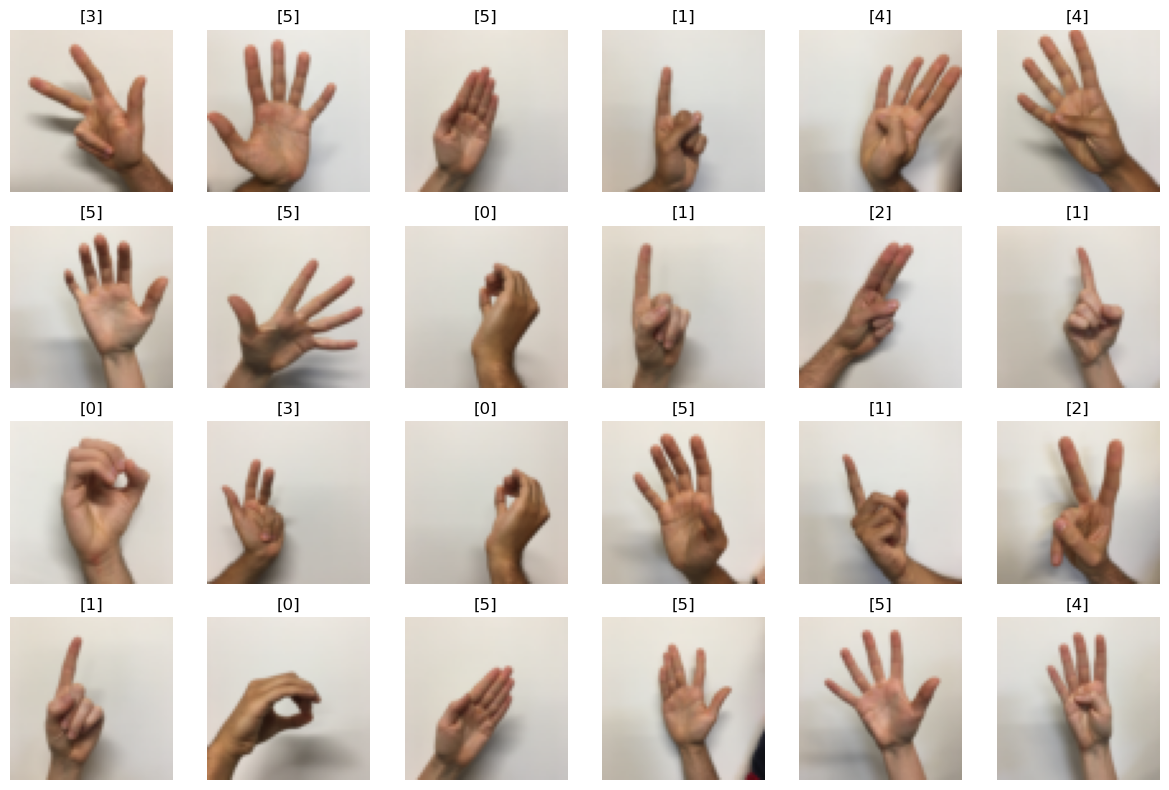

In [7]:
plt.figure(figsize= (12,8))
display_samples_in_grid(train_data, n_rows=4, n_cols=6, y= train_labels.T)
plt.tight_layout(h_pad=1, w_pad=1)

In [10]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import itertools

In [19]:
train_data, train_labels, test_data, test_labels, classes = load_dataset()

X_train_norm = train_data / 255.0
X_test_norm = test_data / 255.0

y_train_norm = train_labels.T.squeeze()
y_test_norm = test_labels.T.squeeze()

In [20]:
def create_model(num_layers=2, activation='relu', dropout_rate=0.3):
    model = models.Sequential()
    model.add(layers.Flatten(input_shape=(64, 64, 3)))
    
    model.add(layers.BatchNormalization())
    
    if num_layers == 1:
        model.add(layers.Dense(128, activation=activation))
        model.add(layers.BatchNormalization())
    elif num_layers == 2:
        model.add(layers.Dense(128, activation=activation))
        model.add(layers.BatchNormalization())
        model.add(layers.Dense(64, activation=activation))
        model.add(layers.BatchNormalization())
    elif num_layers == 3:
        model.add(layers.Dense(256, activation=activation))
        model.add(layers.BatchNormalization())
        model.add(layers.Dense(128, activation=activation))
        model.add(layers.BatchNormalization())
        model.add(layers.Dense(64, activation=activation))
        model.add(layers.BatchNormalization())
        
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))
        
    model.add(layers.Dense(6, activation='softmax'))
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

використаю Grid Search для пошуку найкращих параметрів 

In [23]:
param_grid = {
    'num_layers': [1, 2, 3, 4],
    'activation': ['tanh', 'sigmoid', 'relu'],
    'dropout_rate': [0.3, 0.5, 0.66]
}

keys, values = zip(*param_grid.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

best_accuracy = 0.0
best_config = None
best_model = None


for i, config in enumerate(experiments):
    print(f"Експеримент {i+1}/{len(experiments)} | Шари: {config['num_layers']}, Активація: {config['activation']}, Dropout: {config['dropout_rate']}")
    
    model = create_model(
        num_layers=config['num_layers'], 
        activation=config['activation'], 
        dropout_rate=config['dropout_rate']
    )
    

    history = model.fit(
        X_train_norm, y_train_norm,
        epochs=30,
        batch_size=32,
        validation_data=(X_test_norm, y_test_norm),
        verbose=0
    )
    
    test_loss, test_accuracy_current = model.evaluate(X_test_norm, y_test_norm, verbose=0)
    print(f"  -> Точність на тесті: {test_accuracy_current:.4f}")
    
    if test_accuracy_current > best_accuracy:
        best_accuracy = test_accuracy_current
        best_config = config
        best_model = model

print("\n" + "="*50)
print(f"Найкращі параметри: {best_config}")
print(f"Найкраща точність на тесті: {best_accuracy:.4f}")
print("="*50 + "\n")

Експеримент 1/36 | Шари: 1, Активація: tanh, Dropout: 0.3
  -> Точність на тесті: 0.9083
Експеримент 2/36 | Шари: 1, Активація: tanh, Dropout: 0.5
  -> Точність на тесті: 0.9000
Експеримент 3/36 | Шари: 1, Активація: tanh, Dropout: 0.66
  -> Точність на тесті: 0.8750
Експеримент 4/36 | Шари: 1, Активація: sigmoid, Dropout: 0.3
  -> Точність на тесті: 0.9250
Експеримент 5/36 | Шари: 1, Активація: sigmoid, Dropout: 0.5
  -> Точність на тесті: 0.9250
Експеримент 6/36 | Шари: 1, Активація: sigmoid, Dropout: 0.66
  -> Точність на тесті: 0.9083
Експеримент 7/36 | Шари: 1, Активація: relu, Dropout: 0.3
  -> Точність на тесті: 0.9250
Експеримент 8/36 | Шари: 1, Активація: relu, Dropout: 0.5
  -> Точність на тесті: 0.9167
Експеримент 9/36 | Шари: 1, Активація: relu, Dropout: 0.66
  -> Точність на тесті: 0.9500
Експеримент 10/36 | Шари: 2, Активація: tanh, Dropout: 0.3
  -> Точність на тесті: 0.9250
Експеримент 11/36 | Шари: 2, Активація: tanh, Dropout: 0.5
  -> Точність на тесті: 0.9167
Експери

4/4 [==============================] - 0s 7ms/step


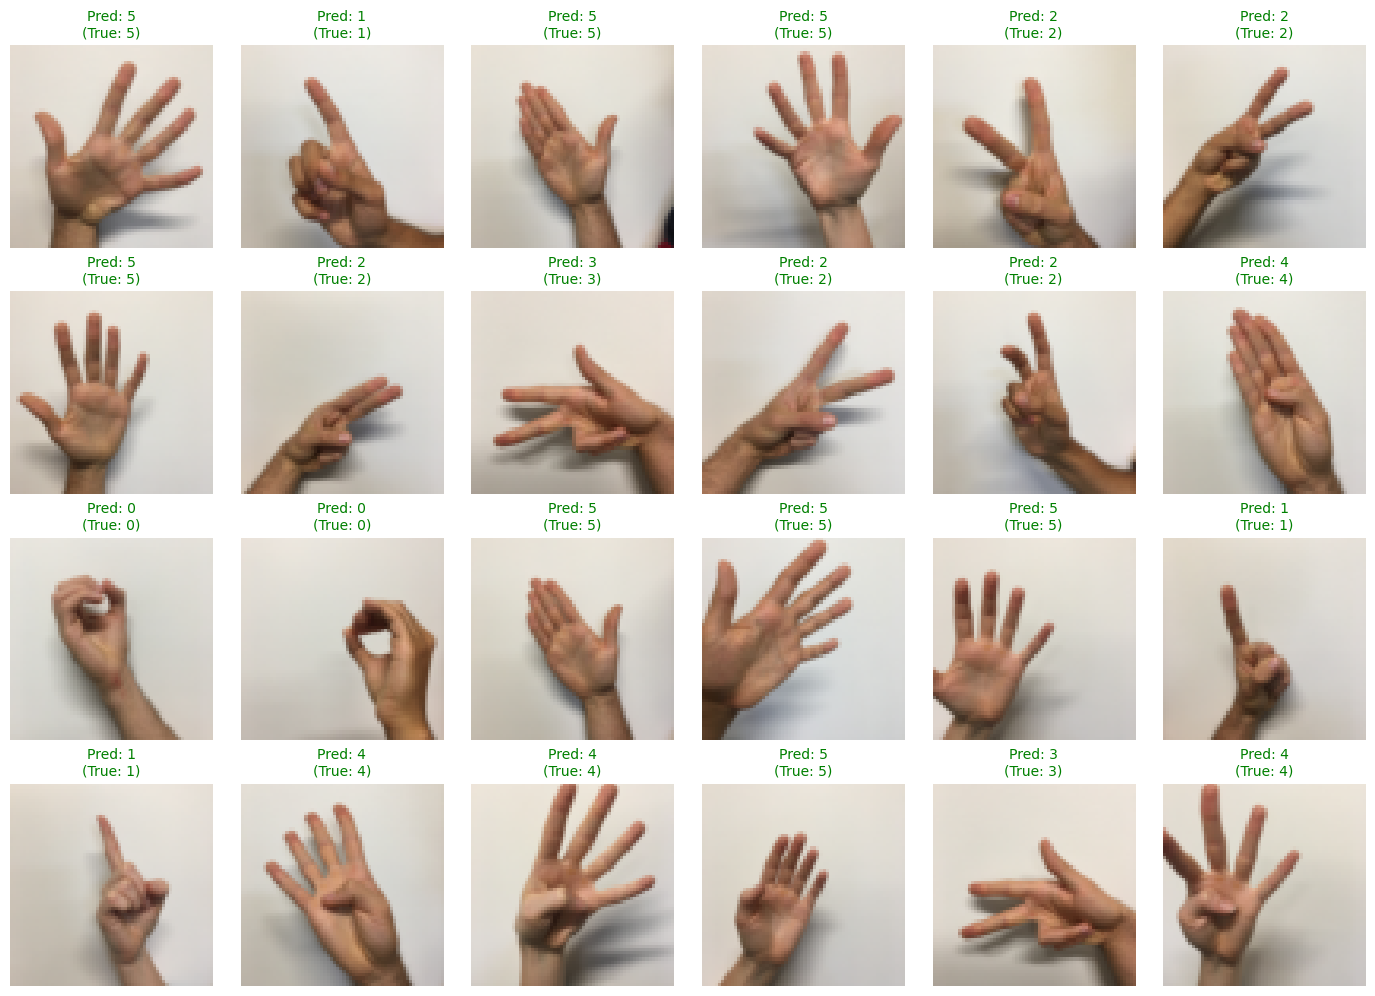

In [24]:
predictions = best_model.predict(X_test_norm)
predicted_classes = np.argmax(predictions, axis=1)

def display_best_case_predictions(X, y_true, y_pred, n_rows=4, n_cols=6):
    plt.figure(figsize=(14, 10))
    indices = np.random.randint(0, len(X), n_rows * n_cols)
    
    for i in range(n_rows):
        for j in range(n_cols):
            index = n_cols * i + j
            idx = indices[index]
            
            ax = plt.subplot(n_rows, n_cols, index + 1)
            ax.imshow(X[idx])
            
            true_label = int(y_true[idx])
            pred_label = int(y_pred[idx])
            

            color = 'green' if true_label == pred_label else 'red'
            
            plt.title(f"Pred: {pred_label}\n(True: {true_label})", color=color, fontsize=10)
            plt.axis('off')
            

    plt.tight_layout(h_pad=1.5, w_pad=1.0)
    plt.show()

display_best_case_predictions(test_data, y_test_norm, predicted_classes, n_rows=4, n_cols=6)